In [197]:
import numpy as np

In [198]:
def assemble_K(N, a=1.0):
    """Saml stivhedsmatricen K for N indre knudepunkter, konstant a."""
    h = 1.0 / (N + 1)
    K = np.zeros((N, N))
    for k in range(N):
        x_k = (k+1)*h  # knudepunktets position
        x_pk = (k+2)*h
        x_mk = (k)*h
        K[k, k] = a*(1/(x_k-x_mk)-1/(x_k-x_pk))  # diagonalindgang
        if k > 0:
            K[k, k-1] = -1*a/h  # nedre naboindgang
        if k < N - 1:
            K[k, k+1] = -1*a/h  # øvre naboindgang
    return K

def assemble_p(N):
    """Saml lastvektoren p for p(x) = 1."""
    h = 1.0 / (N + 1)  # skridtlængde
    return [h]*N

def fem_solution(x_fine, u_coeffs, N):
    """Evaluer FEM-løsningen på et fint gitter via stykkevis lineær interpolation."""
    u_full = np.concatenate([[0.0], u_coeffs, [0.0]])
    x_nodes = np.linspace(0, 1, N + 2)
    #print ("aprox is", np.interp(x_fine, x_nodes, u_full))
    return np.interp(x_fine, x_nodes, u_full)


def l2_error(N):
    """Beregn L2-fejlnormen F(N) = ||u - u_hat||_2."""
    K = assemble_K(N)
    p_vec = assemble_p(N)
    u = np.linalg.solve(K, p_vec)
    x_fine = np.linspace (0,1,N)
    u_approx = fem_solution(x_fine, u, N)
    u_exact = x_fine * (1-x_fine)/2
    #print ("u is", u_exact)
    return (np.sqrt(np.trapz((u_exact - u_approx)**2)))

l2_error(2)

0.0

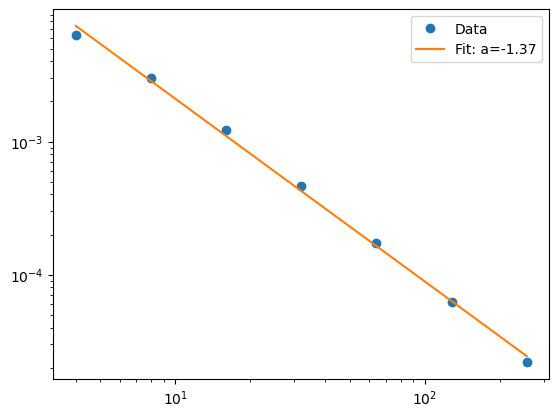

In [199]:
import matplotlib.pyplot as plt
z=[4,8,16,32,64,128,256]
x_p=[]
y_p=[]
for n in z:
    x_p.append(n)
    y_p.append(l2_error(n))

#plt.plot(x_p,y_p)
#plt.loglog(x_p,y_p)
#plt.show


log_x = np.log(x_p)
log_y = np.log(y_p)

a, b = np.polyfit(log_x,log_y,1)

def func(x):
    return np.exp(b) * x**a


plt.loglog(x_p, y_p, 'o', label="Data")
plt.loglog(x_p, func(np.array(x_p)), label=f"Fit: a={a:.2f}")
plt.legend()
plt.show()